<a href="https://colab.research.google.com/github/sadaf-iqbal17/Pytorch/blob/main/Basic_Neura_Network_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [145]:
import torch
import torch.nn as nn    #torch has neural network library thing  we are using that here
import torch.nn.functional as F    # this will allow  us to move our data forward in the function

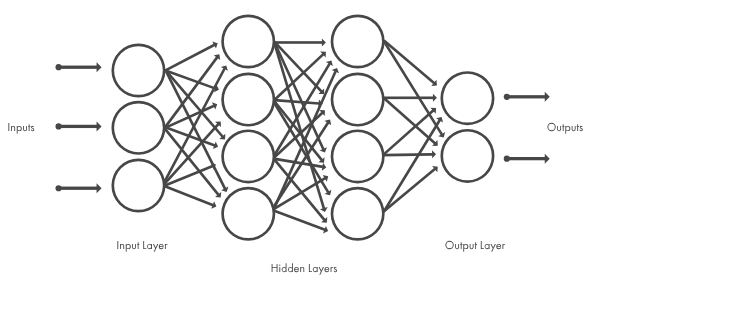

**Create a model class that inherits nn.Model**

In [146]:
class Model(nn.Module):
  # This line defines a new class called 'Model'.
  # It inherits from 'nn.Module', which is the base class for all neural network modules in PyTorch.
  # This means our 'Model' class will have all the functionalities of a PyTorch neural network.

  # These comments describe the overall structure of our neural network:
  # - input layer: Takes 4 features (Sepal length, Sepal width, Petal length, Petal width).
  # - hidden layer 1 (h1): An intermediate layer with a certain number of neurons.
  # - hidden layer 2 (h2): Another intermediate layer.
  # - output layer: Produces 3 outputs, corresponding to the three types of iris flowers we want to classify.

  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    # This is the constructor method, called when you create a new instance of the 'Model' class.
    # 'self' refers to the instance of the class being created.
    # 'in_features': The number of input features (4 for our iris dataset).
    # 'h1': The number of neurons in the first hidden layer (we chose 8).
    # 'h2': The number of neurons in the second hidden layer (we chose 9).
    # 'out_features': The number of output features (3 for the three iris classes).

    super().__init__()
    # This line calls the constructor of the parent class (nn.Module).
    # It's essential to properly initialize the base neural network functionality.

    self.fc1 = nn.Linear(in_features, h1)
    # This creates the first 'fully connected' layer (fc1).
    # 'nn.Linear' creates a linear transformation (y = xA^T + b).
    # It takes 'in_features' as input and produces 'h1' outputs.
    # This connects the input layer to the first hidden layer.

    self.fc2 = nn.Linear(h1, h2)
    # This creates the second fully connected layer (fc2).
    # It takes the output from fc1 (which has 'h1' features) and produces 'h2' outputs.
    # This connects the first hidden layer to the second hidden layer.

    self.out = nn.Linear(h2, out_features)
    # This creates the output layer.
    # It takes the output from fc2 (which has 'h2' features) and produces 'out_features' (3) outputs.
    # This connects the second hidden layer to the final output layer.
    # 'fc' stands for fully connected, meaning every neuron in the previous layer is connected to every neuron in the current layer.

  # This method defines how data flows forward through the neural network.
  def forward(self, x):
    # 'x' is the input data (e.g., a batch of flower features).

    x = F.relu(self.fc1(x))
    # First, the input 'x' is passed through the first fully connected layer (self.fc1).
    # The output of self.fc1(x) is then passed through the ReLU (Rectified Linear Unit) activation function.
    # ReLU function: if the output is less than 0, it becomes 0; otherwise, it remains unchanged.
    # This introduces non-linearity, allowing the model to learn complex patterns.

    x = F.relu(self.fc2(x))
    # The output from the previous step is now passed through the second fully connected layer (self.fc2).
    # Again, the result is processed by the ReLU activation function.

    x = self.out(x)
    # Finally, the output from the second hidden layer is passed through the output layer (self.out).
    # This layer produces the raw scores (logits) for each of the three iris classes.

    return x
    # The method returns the final output of the network.

In [147]:
# Create a manual seed because neural network initialization involves randomization.
# This ensures that if you run the code multiple times, you get the same 'random' starting weights for reproducibility.
torch.manual_seed(41)   # 41 is just a chosen random number to seed the random number generator.

# Create an instance of the Model class we defined earlier.
# This initializes our neural network with the specified input, hidden, and output layer sizes.
# The 'model' object now contains all the layers (fc1, fc2, out) and their initial weights.
model = Model()

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [149]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [150]:
#Change last column from strings to integers
my_df['species'] = my_df['species'].replace('setosa', 0.0)
my_df['species'] = my_df['species'].replace('versicolor', 1.0)
my_df['species'] = my_df['species'].replace('virginica', 2.0)
my_df

/tmp/ipykernel_376/701019244.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica', 2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [151]:
#Train Test Split  Set X , y
# This line creates a new DataFrame `X` by dropping the 'species' column from `my_df`.
# `axis=1` specifies that a column is being dropped. `X` will contain the input features.
X = my_df.drop('species', axis=1)

# This line creates a Series `y` containing only the 'species' column from `my_df`.
# `y` will serve as the target labels for our model.
y=my_df['species']

In [152]:
#Convert these to numpy arrays
X= X.values
y=y.values

In [153]:
from sklearn.model_selection import train_test_split

In [154]:
#Train Test Split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=26 )

In [155]:
#Convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [156]:
#Convert y labels to tensors long
y_train = torch.LongTensor(y_train)
y_test =  torch.LongTensor(y_test)

In [157]:
#now we will set the criteria of our model to test error , how far off the predictions are from teh data
criterion = nn.CrossEntropyLoss()
#Choose Adam optimizer  , learning rate ( lr) if our error doesn't go down after a bunch of iterations (epochs) so we wil probably lower down our learning rate
#lower the learning rate it will take mor time and hence give the accurate results
optimizer = torch.optim.Adam(model.parameters() , lr = 0.01)
model.parameters



<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [158]:
#Train ourr model
#Epochs (one run through all the training sata in our network)
epochs = 100
losses =[]
for i in range(epochs):
    #Go forward and get a prediction
    y_pred = model.forward(X_train)  #Get prediction results

    #Measure teh error or loss ( it will be hig at first)
    #we will create a losss variable
    loss = criterion(y_pred, y_train)  #predicted values vs the y_train
    #keep track of losses
    losses.append(loss.detach().numpy())
    #print everey 1- epochs
    if i % 10==0:
        print(f'Epoch:  {i}  and loss : {loss}')
    #Do som eback propogation   : take the error rate  of forward propogation and feed it back through the network to fine tune the weights
    optimizer .zero_grad()
    loss.backward()
    optimizer.step()

Epoch:  0  and loss : 1.1237820386886597
Epoch:  10  and loss : 1.0204154253005981
Epoch:  20  and loss : 0.8342276215553284
Epoch:  30  and loss : 0.6023485064506531
Epoch:  40  and loss : 0.41549476981163025
Epoch:  50  and loss : 0.29010722041130066
Epoch:  60  and loss : 0.20372374355793
Epoch:  70  and loss : 0.1483089178800583
Epoch:  80  and loss : 0.11296287178993225
Epoch:  90  and loss : 0.09252995997667313


Text(0.5, 0, 'epochs')

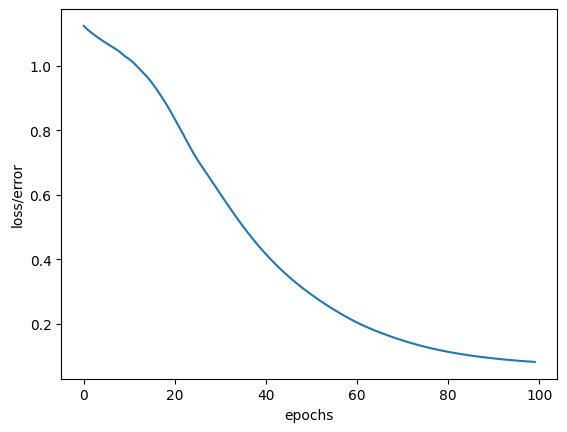

In [159]:
#Graph it out
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel("epochs")

**Evaluate model on test data set (validate model on test data set_**

In [160]:
with torch.no_grad():   #basically turn off back propogation
  y_eval = model.forward(X_test)   #X_test are featues from our test daa and  y_eval will be predictions
  loss = criterion(y_eval , y_test)  #find the loss or error


In [161]:
loss

tensor(0.0280)

In [162]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)
    if y_test[i] == 0:
      x="setosa"
    elif y_test[i] ==1:
      x="versicolor"
    else:
      x="virgincolor"


    #it tells us what type of flower our network think it is
    print(f'{i+1}.) {str(y_val)}  \t {y_test[i]} \t {y_val.argmax().item()}')
    #checking correct or not
    if y_val.argmax().item() == y_test[i]:
     correct +=1
print(f'we got {correct} correct')

1.) tensor([-4.3886,  5.7905,  2.0536])  	 1 	 1
2.) tensor([-3.5763,  4.9660,  1.6637])  	 1 	 1
3.) tensor([ 4.2573, -1.8402, -2.7580])  	 0 	 0
4.) tensor([ 4.5229, -2.1064, -2.8542])  	 0 	 0
5.) tensor([-6.2734,  4.4743,  6.6869])  	 2 	 2
6.) tensor([-2.7605,  4.5669,  0.7707])  	 1 	 1
7.) tensor([ 4.4469, -2.0260, -2.8304])  	 0 	 0
8.) tensor([-7.2563,  5.4946,  7.1344])  	 2 	 2
9.) tensor([-8.4253,  4.7717,  9.8521])  	 2 	 2
10.) tensor([-6.6344,  4.1485,  7.6556])  	 2 	 2
11.) tensor([ 3.6618, -1.3039, -2.4891])  	 0 	 0
12.) tensor([-3.9099,  5.6970,  1.3636])  	 1 	 1
13.) tensor([-3.0310,  4.8337,  0.9082])  	 1 	 1
14.) tensor([ 4.1275, -1.7623, -2.6652])  	 0 	 0
15.) tensor([-2.8041,  4.6347,  0.7920])  	 1 	 1
16.) tensor([ 4.6448, -2.2471, -2.8822])  	 0 	 0
17.) tensor([-6.7104,  3.6304,  8.3530])  	 2 	 2
18.) tensor([-2.0332,  3.9028,  0.3854])  	 1 	 1
19.) tensor([-6.8600,  4.9191,  7.1408])  	 2 	 2
20.) tensor([ 4.3249, -1.9376, -2.7564])  	 0 	 0
21.) tens

In [163]:
# random state mattes a lot to get the correct results

In [ ]:
**Feeding new data in our network to make predictions**

In [172]:
new_iris = torch.tensor([1.4, 2.1 , 2.3 , 1.4])
#we will pass this new data to teh model to check which type of flower it is
with torch.no_grad():
  model_output = model(new_iris)
  print(model_output , model_output.argmax().item())

tensor([-1.8497,  1.8609,  2.4151]) 2


**Save and Load our Neural Network Model**

In [173]:
torch.save(model.state_dict(), 'my_iris_model.pt')

**Load our saved model**

In [176]:
new_model = Model()
new_model.load_state_dict(torch.load('my_iris_model.pt'))

<All keys matched successfully>

**Make sure it is loaded successfully**

In [177]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)